In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from itertools import combinations
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [27]:
# Load dataset
df = pd.read_csv("Training Set_21.csv",index_col=0)
df

,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),...,diff_NPA(C28),SP_HOMO_L,SP_LUMO_L,SP_LU-HO_L,SP_μ_L,SP_η_L,Tolman_CA_int,B1_Sp2,B5_Sp2,L_Sp2
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,1.00,2.00,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,...,-0.065,-0.30016,0.05309,0.35325,-0.123535,0.176625,195.44,2.02,4.48,7.46
5-IMes(Me),1.00,1.80,-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,...,-0.074,-0.29041,0.05333,0.34374,-0.118540,0.171870,195.44,2.05,4.47,7.46
5-IPr,1.80,1.00,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,...,-0.055,-0.30363,0.05130,0.35493,-0.126165,0.177465,208.69,2.83,5.71,6.41
"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,...,-0.063,-0.30069,0.04423,0.34492,-0.128230,0.172460,246.68,4.00,8.05,7.46
5-IPr**,6.14,1.00,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,...,-0.052,-0.29232,0.03967,0.33199,-0.126325,0.165995,262.56,6.79,10.80,7.47
5-IPr*,6.50,1.00,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,...,-0.052,-0.29907,0.03739,0.33646,-0.130840,0.168230,262.78,5.32,8.18,7.46
5-IPent,4.00,1.00,0.969348,-2354.1126,-2355.0496,0.936960,-2356.6538,2.07486,1.98351,166.60027,...,-0.044,-0.30297,0.04913,0.35210,-0.126920,0.176050,229.49,4.32,6.48,6.41
5-Np#,1.40,1.00,0.235274,-4882.1648,-4883.7215,1.556706,-4885.8399,2.05552,1.98500,162.73663,...,-0.049,-0.28387,0.00880,0.29267,-0.137535,0.146335,261.73,4.92,10.24,10.22
5-IEt,1.00,1.33,-0.199408,-1961.3491,-1962.0085,0.659387,-1963.5345,2.06528,1.98437,174.90785,...,-0.063,-0.30067,0.04922,0.34989,-0.125725,0.174945,194.07,2.27,5.30,7.46


In [28]:
parm = ['ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)', 'HOMO_L', 'LUMO_L',
       'LU-HO_L', 'μ_L', 'η_L', 'BA(N-C-N)_L', 'NPA(C28)_L', 'diff_NPA(C28)',
       'SP_HOMO_L', 'SP_LUMO_L', 'SP_LU-HO_L', 'SP_μ_L', 'SP_η_L',
       'Tolman_CA_int', 'B1_Sp2', 'B5_Sp2', 'L_Sp2']
df_x = df[parm]
scaler = StandardScaler()
df[parm] = scaler.fit_transform(df_x)

In [29]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn import metrics

x = df[['B5_Sp2','B1_Sp2','%Vbur(3.0Å)','E_Pd(LP)']]
y = df[['ΔΔG_Exp']]
x_array = np.array(x)
y_array = np.array(y)
loo = LeaveOneOut()
y_testall = []
y_predall = []
for train_i, test_i in loo.split(x):
    x_train, x_test = x_array[train_i], x_array[test_i]
    y_train, y_test = y_array[train_i], y_array[test_i]
    
    model = LinearRegression()
    model.fit(X = x_train, y = y_train)
    y_pred = model.predict(x_test)
    
    y_testall += list(y_test)
    y_predall += list(y_pred)
    
rr = metrics.r2_score(y_testall, y_predall)
ms_error = metrics.mean_squared_error(y_testall, y_predall)

print("r2 =", rr, ",", "rmse =", ms_error)

r2 = 0.8085705224383801 , rmse = 0.07938845746992437


In [30]:
x1 = df[['B5_Sp2','B1_Sp2','%Vbur(3.0Å)','E_Pd(LP)']]
y1 = df['ΔΔG_Exp']
regr = linear_model.LinearRegression()
regr.fit(x1,y1)
y_pred1 = regr.predict(x1)
r2 = regr.score(x1,y1)
print("rmse =", mean_squared_error(y1, y_pred1))
print("r2 =", regr.score(x1,y1))
print(regr.coef_)
print(regr.intercept_)

rmse = 0.04085163792207413
r2 = 0.9014943991332527
[-0.37318036  0.38033548  0.31654427 -0.30874259]
0.18768794412833778


In [31]:
df_compare = pd.DataFrame(y_pred1,y1)
df_compare

,0
ΔΔG_Exp,
-0.484674,-0.313798
-0.411002,-0.504063
0.411002,0.334257
0.969348,0.893719
1.268993,1.286665
1.308833,1.508875
0.969348,0.654772
0.235274,0.381904
-0.199408,-0.087760


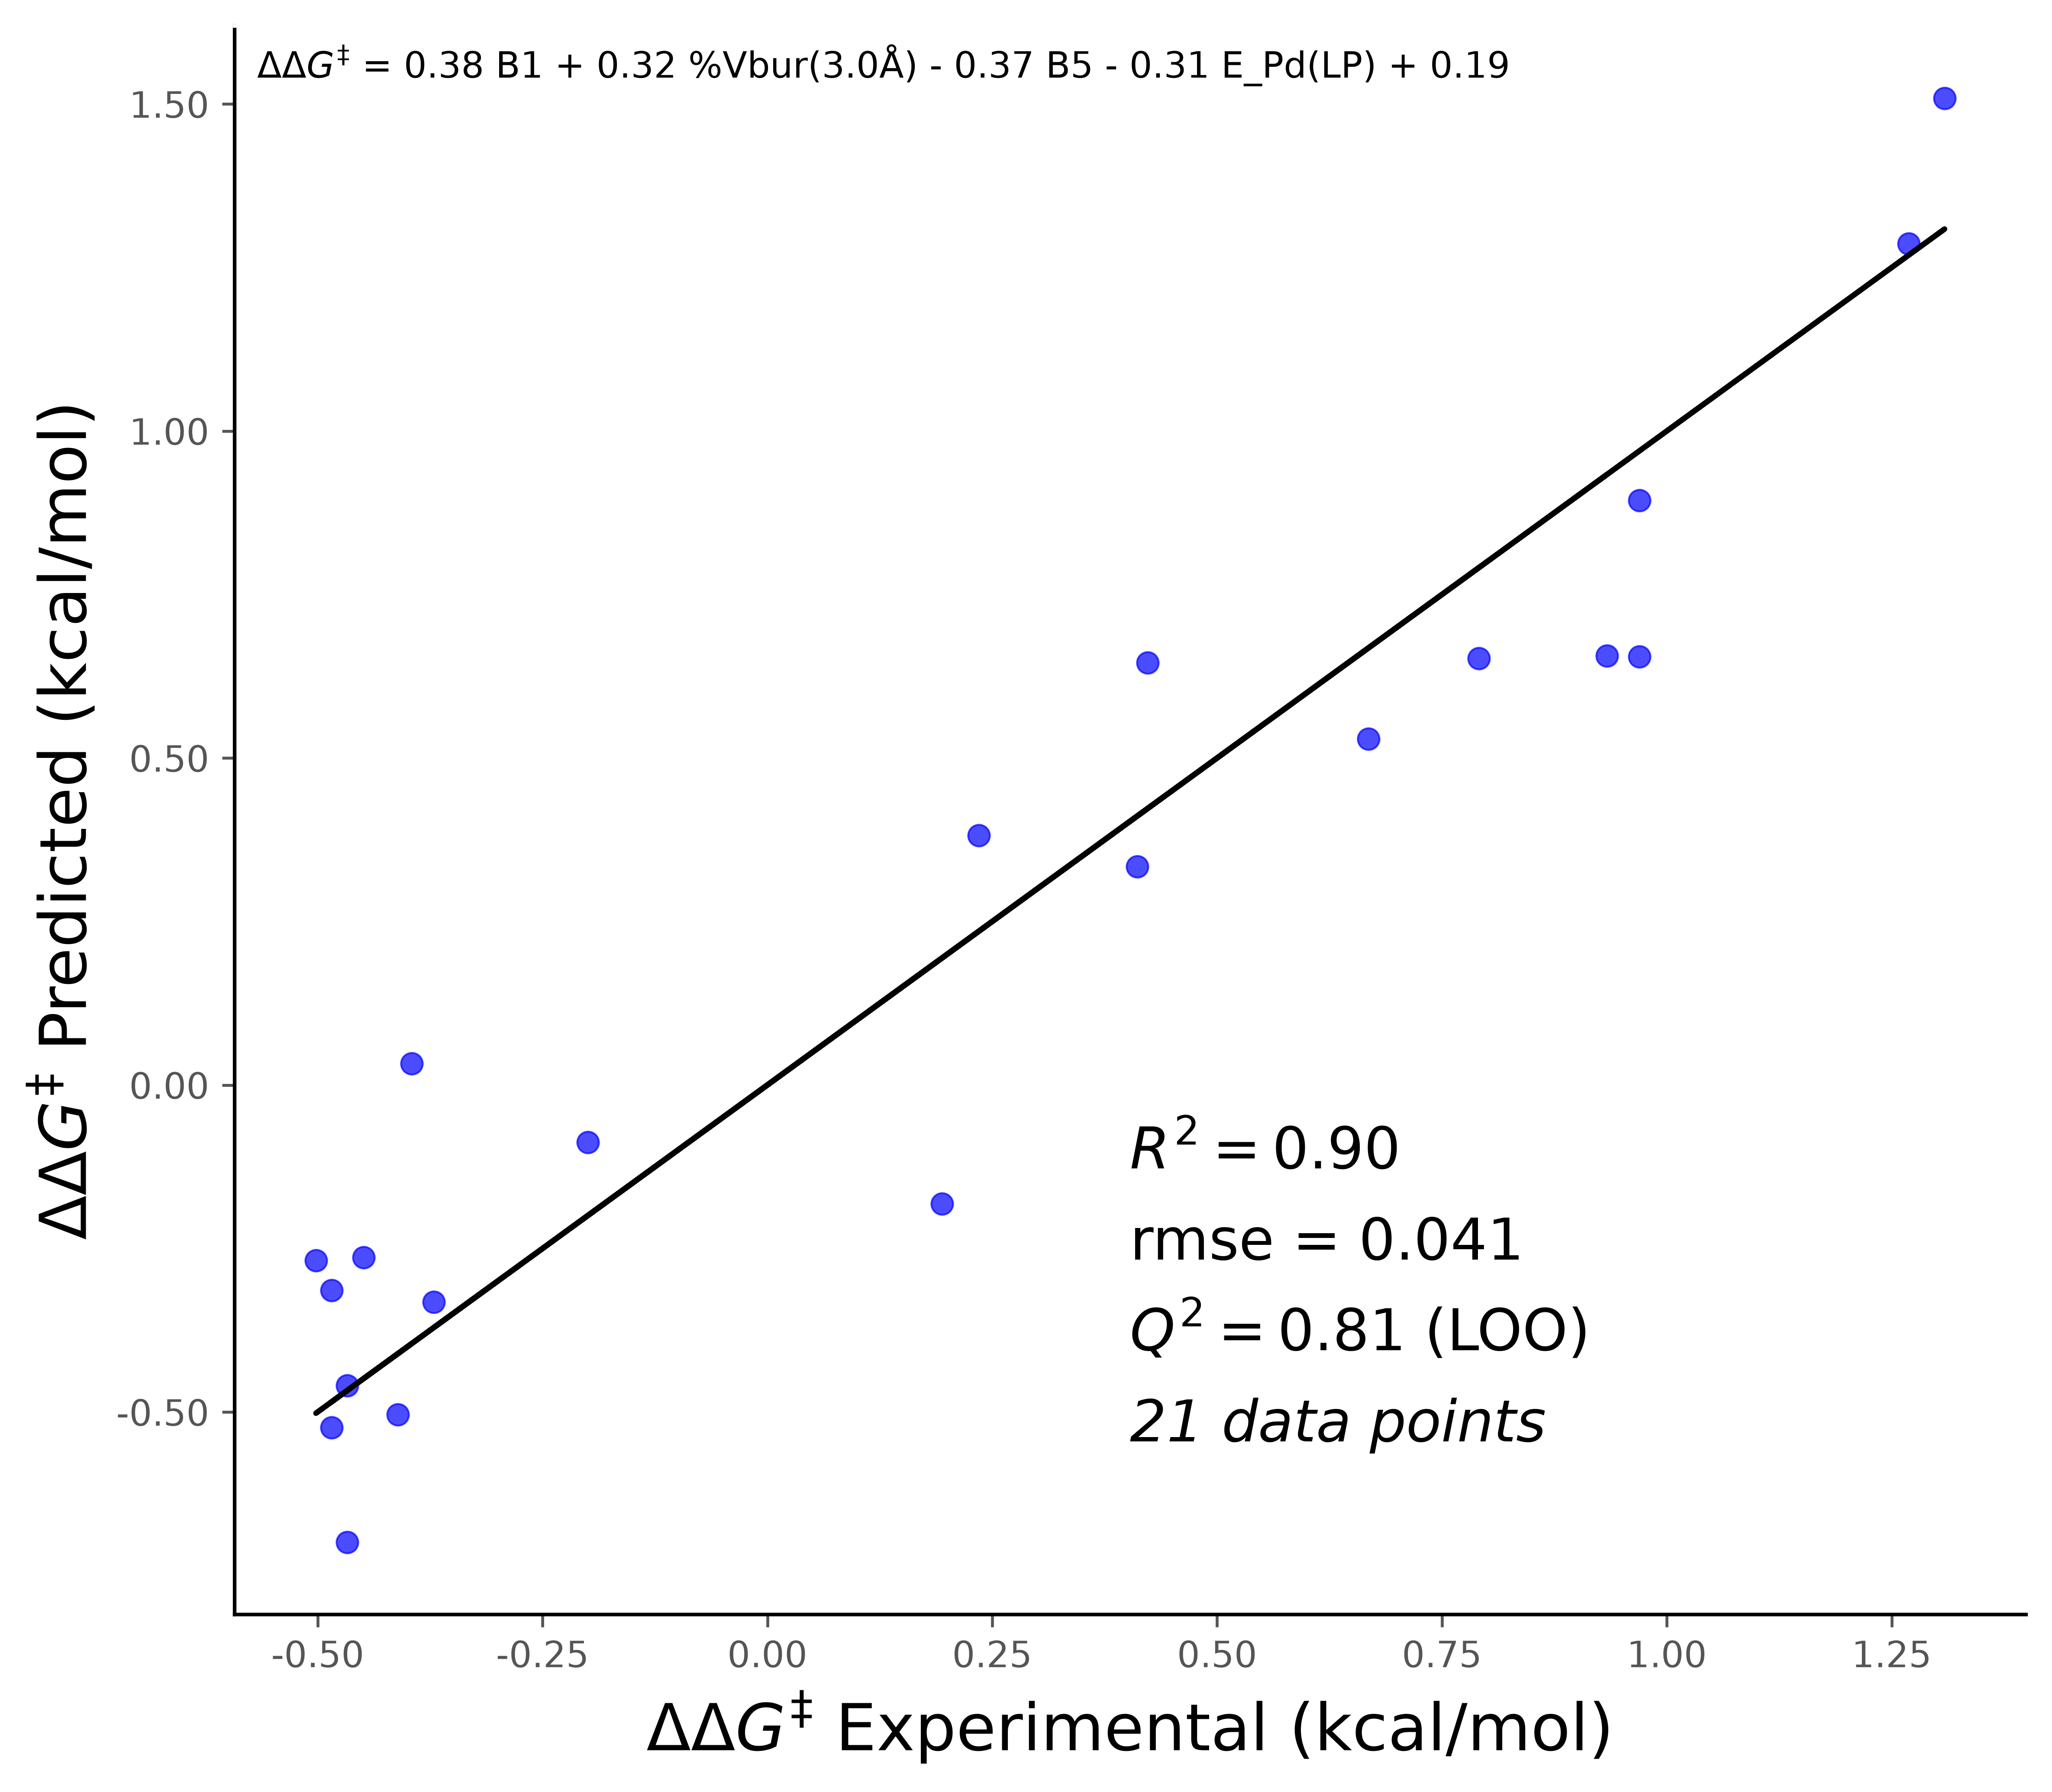

In [32]:
from matplotlib.ticker import FormatStrFormatter

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)
ax.set_ylabel('$\Delta\Delta G^{‡}$ Predicted (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('$\Delta\Delta G^{‡}$ Experimental (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

fig.text(0.13, 0.95, '$\Delta\Delta G^{‡}$ = 0.38 B1 + 0.32 %Vbur(3.0Å) - 0.37 B5 - 0.31 E_Pd(LP) + 0.19', fontsize = 10)
fig.text(0.55, 0.35, '$R^2= 0.90$', fontsize = 16)
fig.text(0.55, 0.30, 'rmse = 0.041', fontsize = 16)
fig.text(0.55, 0.25, '$Q^2= 0.81$ (LOO)', fontsize = 16)
fig.text(0.55, 0.20, '21 data points', fontsize = 16, style = 'italic')
fig.tight_layout()

plt.savefig('LR_21L.png', bbox_inches='tight')

In [33]:
from sklearn.ensemble import RandomForestRegressor
x2 = df[['B5_Sp2','B1_Sp2','%Vbur(3.0Å)','E_Pd(LP)']]
y2 = df['ΔΔG_Exp']
regr = RandomForestRegressor(n_estimators=100, random_state=42)
regr.fit(x2,y2)
y_pred2 = regr.predict(x2)
r2 = regr.score(x2,y2)
print("rmse =", mean_squared_error(y2, y_pred2))
print("r2 =", regr.score(x2,y2))

rmse = 0.010973585461557307
r2 = 0.9735393809272649


In [34]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn import metrics

x3 = df[['B5_Sp2','B1_Sp2','%Vbur(3.0Å)','E_Pd(LP)']]
y3 = df[['ΔΔG_Exp']]
x_array3 = np.array(x3)
y_array3 = np.array(y3)
loo = LeaveOneOut()
y_testall3 = []
y_predall3 = []
for train_i, test_i in loo.split(x3):
    x_train3, x_test3 = x_array3[train_i], x_array3[test_i]
    y_train3, y_test3 = y_array3[train_i], y_array3[test_i]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X = x_train3, y = y_train3)
    y_pred3 = model.predict(x_test3)
    
    y_testall3 += list(y_test3)
    y_predall3 += list(y_pred3)
    
rr = metrics.r2_score(y_testall3, y_predall3)
ms_error = metrics.mean_squared_error(y_testall3, y_predall3)

print("r2 =", rr, ",", "rmse =", ms_error)

/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was exp

r2 = 0.8045219766609764 , rmse = 0.08106744551480893


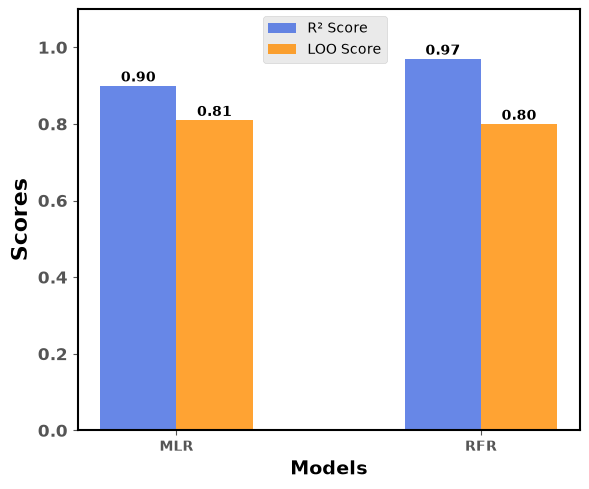

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
models = ['MLR', 'RFR']
r2_scores = [0.90, 0.97]
loo_scores = [0.81, 0.80]

# Bar width and positions
x = np.arange(len(models))
width = 0.25

# Creating the bar chart with a white background
fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")
ax.set_facecolor("white")  # Ensure the plot area is also white

bars1 = ax.bar(x - width/2, r2_scores, width, label='R² Score', color='royalblue', alpha=0.8)
bars2 = ax.bar(x + width/2, loo_scores, width, label='LOO Score', color='darkorange', alpha=0.8)

# Adding value labels on top of bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', fontsize=10, fontweight="bold")

# Labels and title
ax.set_xlabel("Models", fontsize=14, fontweight="bold", color="black")
ax.set_ylabel("Scores", fontsize=16, fontweight="bold", color="black")  # Increased font size
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0)  # Improved readability

# Increase Y-axis limit
ax.set_ylim(0, 1.1)  # Adjust this to increase Y-axis space

# Ensure visible axes (spines)
for spine in ax.spines.values():
    spine.set_edgecolor("black")  # Set axis color
    spine.set_linewidth(1.5)  # Adjust thickness

# Adjust legend position
ax.legend(loc='upper right', bbox_to_anchor=(0.63, 1.0))

# Improve layout
plt.xticks(fontsize=10, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")  # Increased Y-axis tick label size
plt.tight_layout()

# Save the plot with a white background and visible axes
plt.savefig("Figure 4D.png", format="png", dpi=600, bbox_inches="tight", facecolor="white")

# Show plot
plt.show()

In [36]:
B1 = 1.796828
Vbur = 1.353556
B5 = 0.873411
ELP = -1.953707

In [37]:
# Model equation parameters
coefficient_B1 = 0.38033548
coefficient_Vbur = 0.31654427
coefficient_B5 = -0.37318036
coefficient_ELP = -0.30874259
intercept = 0.1876879

In [38]:
Y_pred_V_1 = coefficient_B1 * B1 + coefficient_Vbur * Vbur + coefficient_B5 * B5 + coefficient_ELP * ELP + intercept

In [39]:
print(Y_pred_V_1)

1.57679846365473


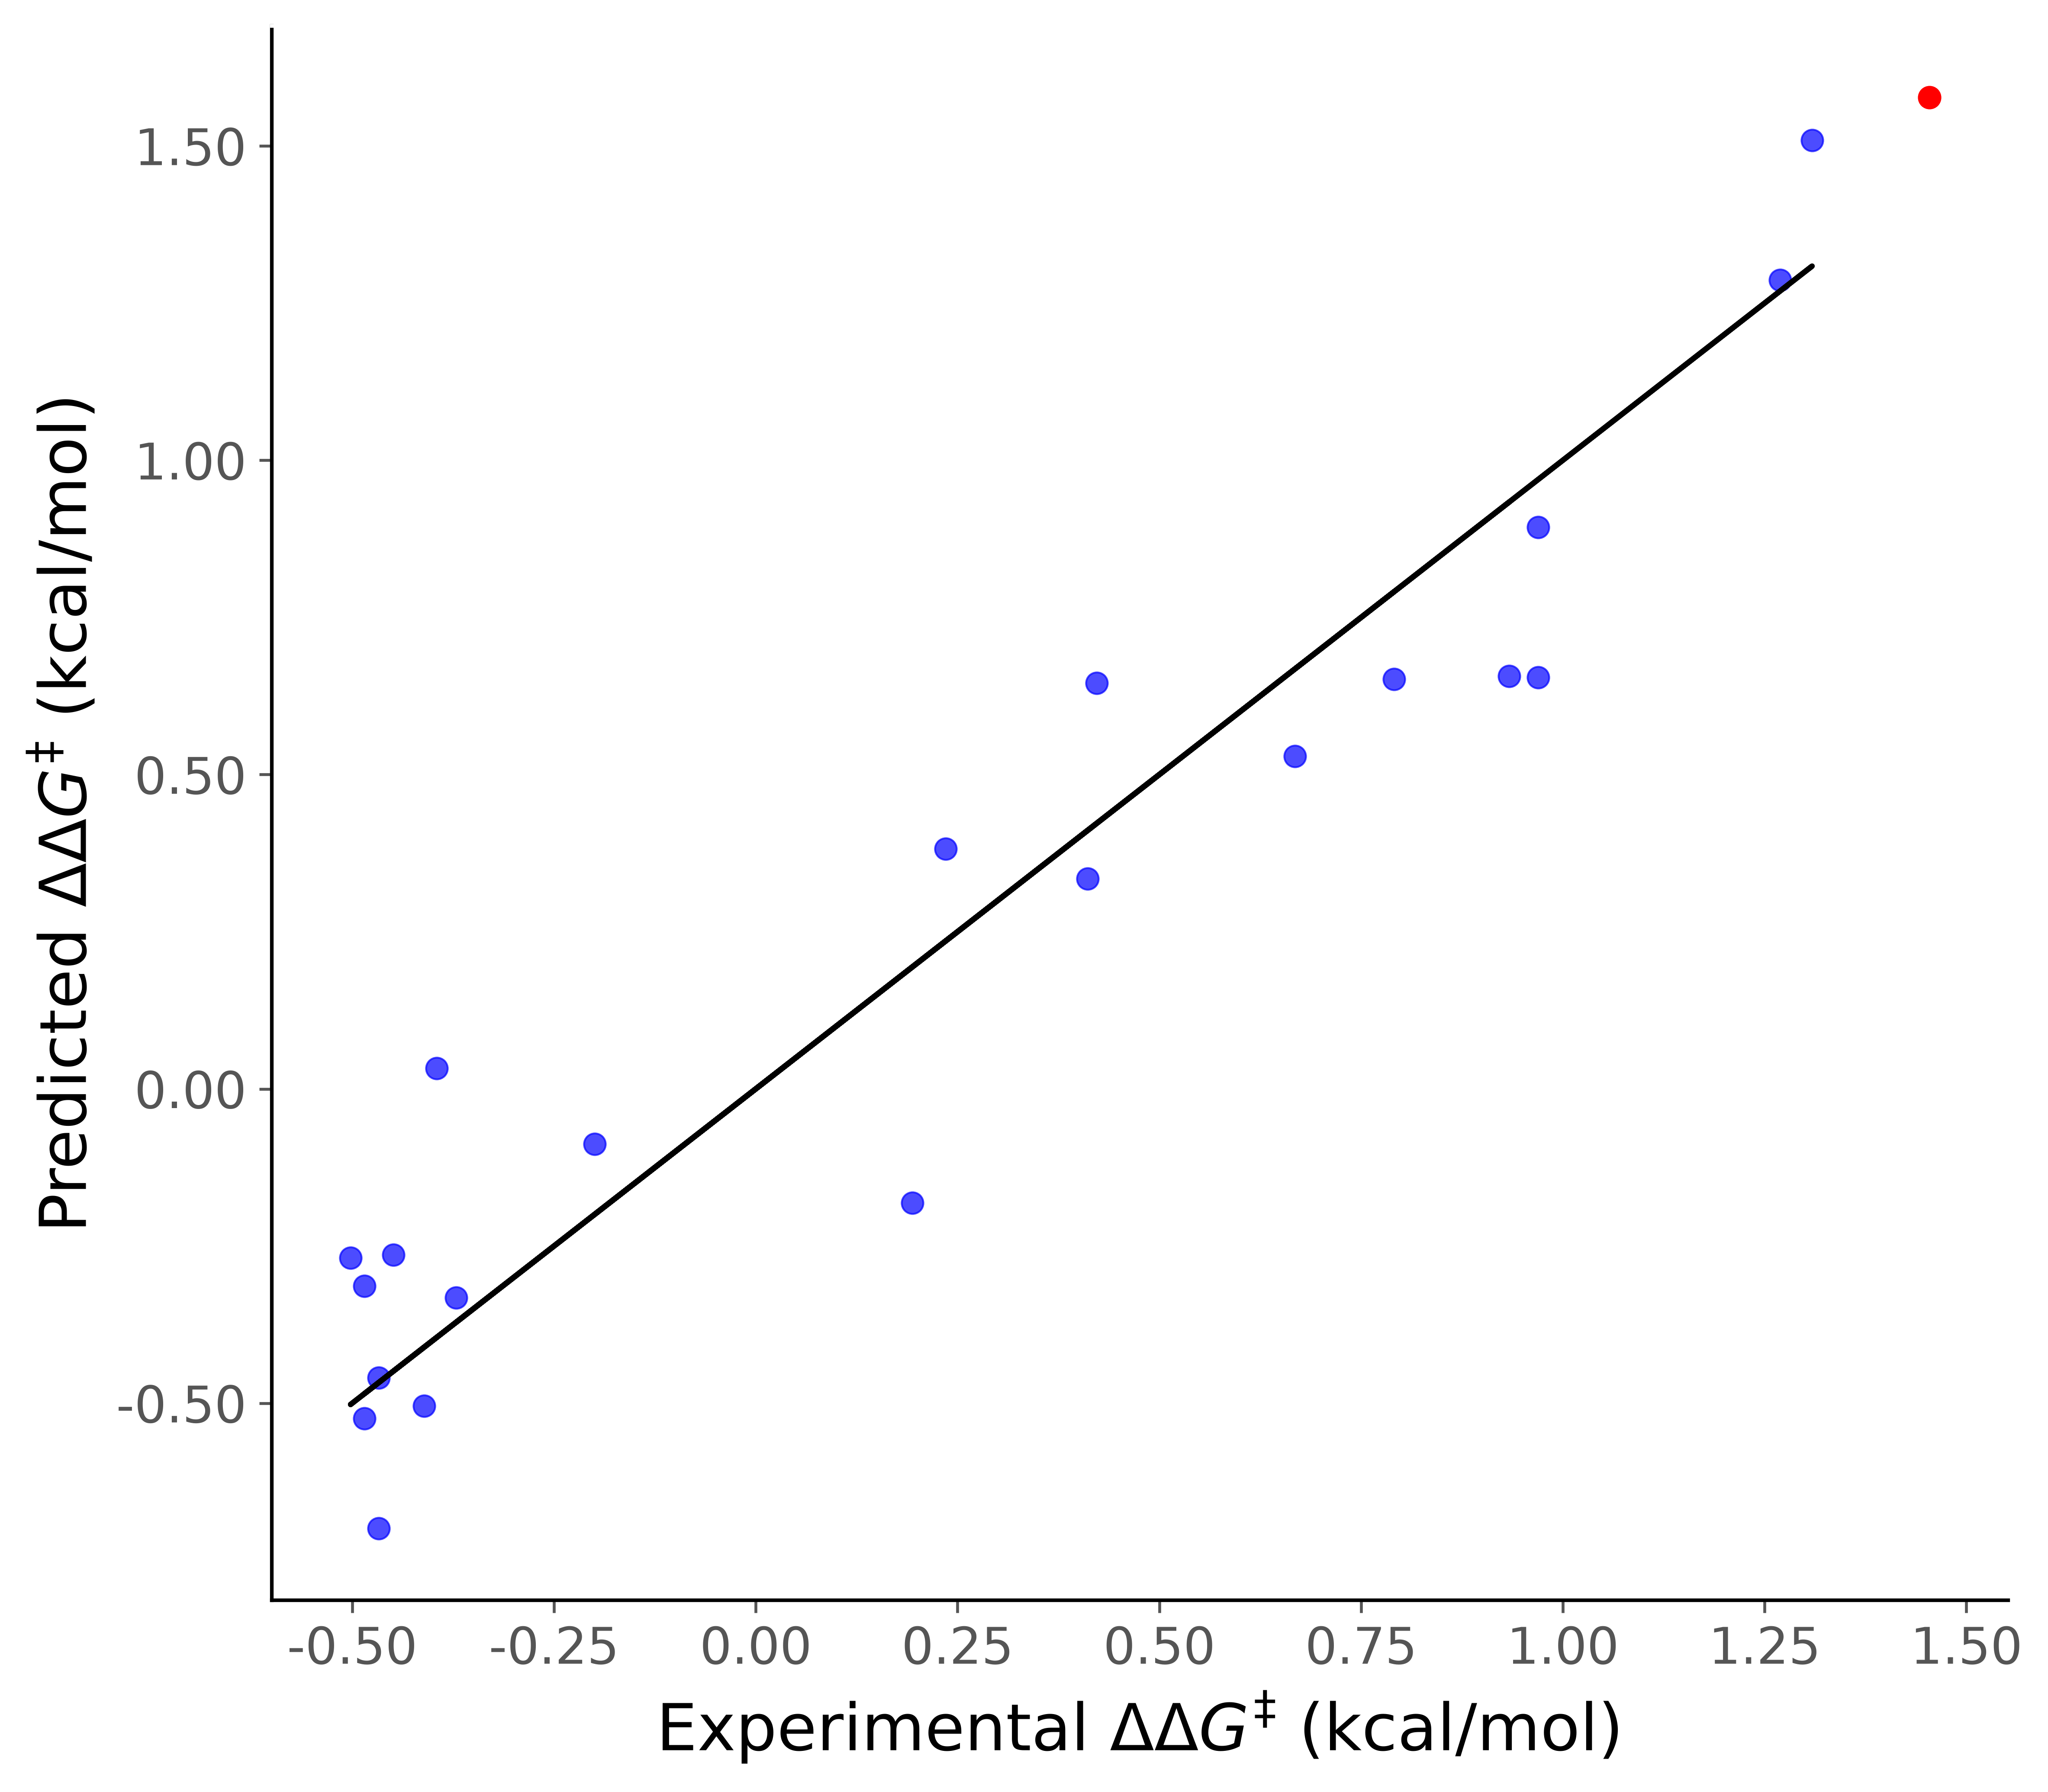

In [40]:
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

# Original plot and scatter
ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)

# New point: Y_actual = 1.454, Y_Pred_V = 1.577 (in red)
ax.scatter(1.454, 1.577, edgecolor='r', facecolor='r', label='New Point')

# Axis labels and formatting
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

fig.tight_layout()

plt.savefig('LR_23L.png', bbox_inches='tight')

In [41]:
B1_1 = 0.008482
Vbur_1 = -0.483780
B5_1 = 0.496870
ELP_1 = 1.313857

In [42]:
# Model equation parameters
coefficient_B1_1 = 0.38033548
coefficient_Vbur_1 = 0.31654427
coefficient_B5_1 = -0.37318036
coefficient_ELP_1 = -0.30874259
intercept_1 = 0.1876879

In [43]:
Y_pred_V_1 = coefficient_B1_1 * B1_1 + coefficient_Vbur_1 * Vbur_1 + coefficient_B5_1 * B5_1 + coefficient_ELP_1 * ELP_1 + intercept_1

In [44]:
print(Y_pred_V_1)

-0.55328961994207


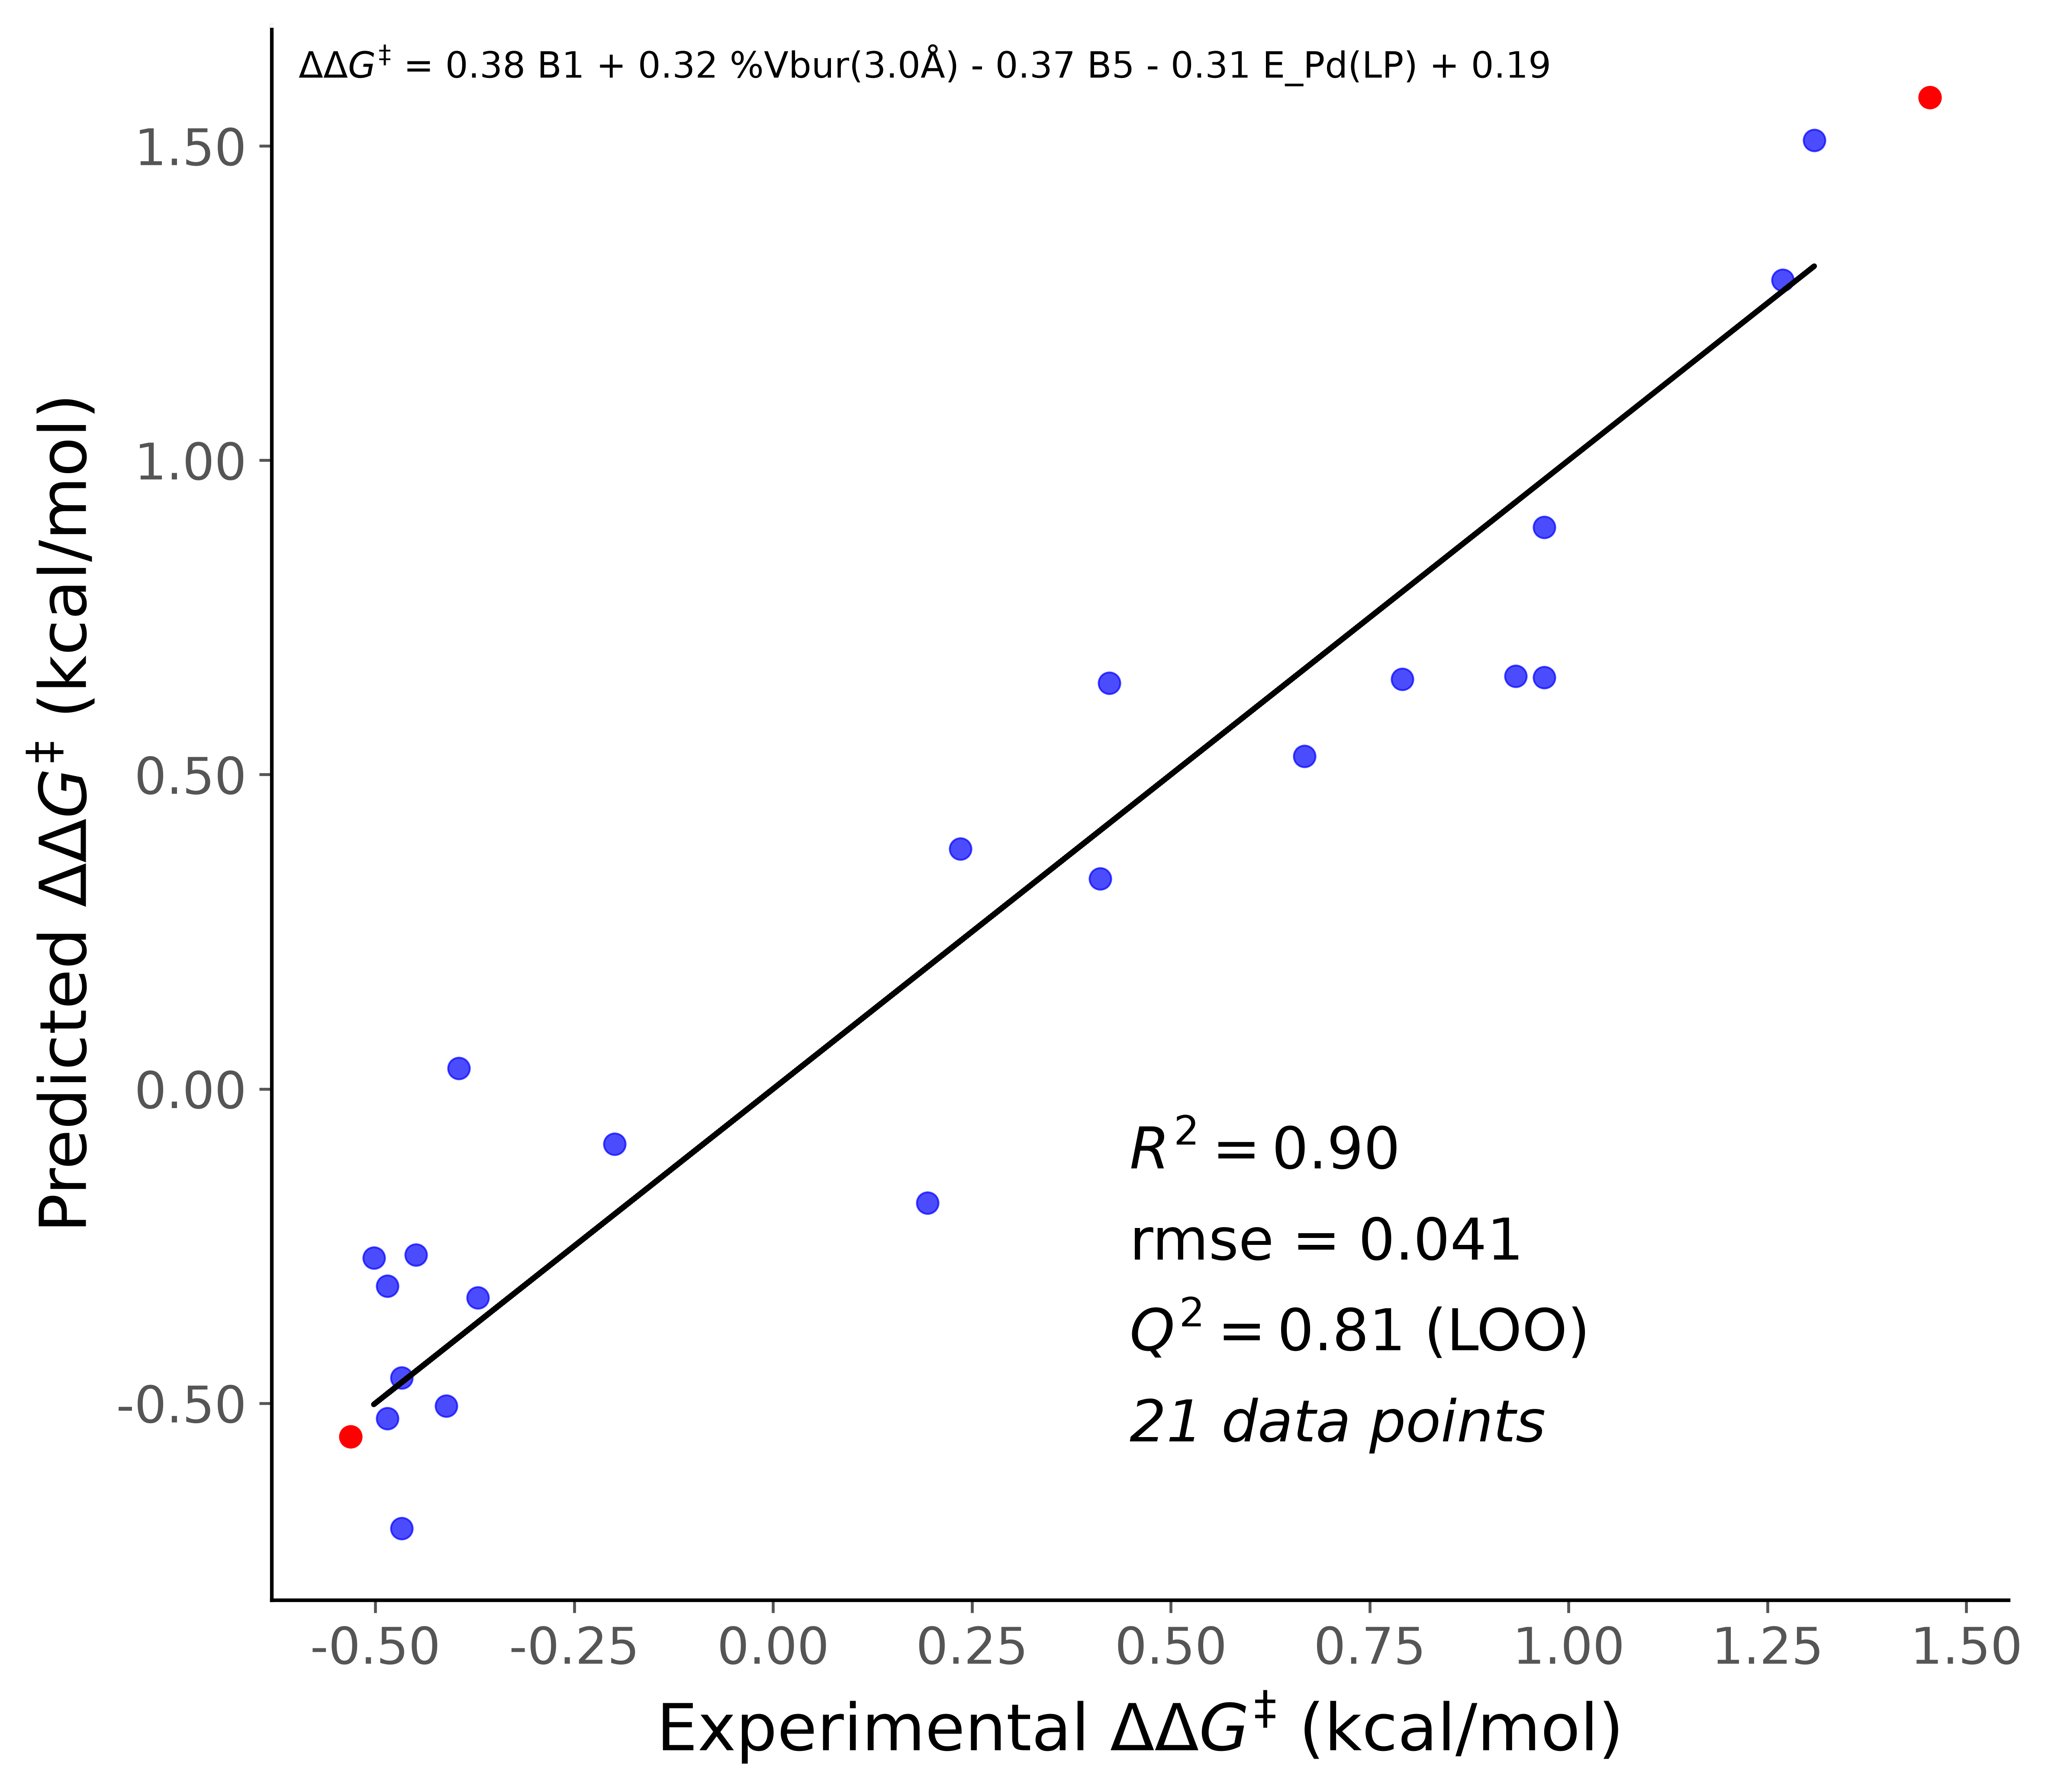

In [45]:
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

# Original plot and scatter
ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)

# New point: Y_actual = -0.541718, Y_Pred_V = 0.02086 (in red)
ax.scatter(1.454, 1.577, edgecolor='r', facecolor='r', label='New Point')
ax.scatter(-0.531, -0.553, edgecolor='r', facecolor='r', label='New Point')

# Axis labels and formatting
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

fig.text(0.15, 0.95, '$\Delta\Delta G^{‡}$ = 0.38 B1 + 0.32 %Vbur(3.0Å) - 0.37 B5 - 0.31 E_Pd(LP) + 0.19', fontsize = 10)
fig.text(0.55, 0.35, '$R^2= 0.90$', fontsize = 16)
fig.text(0.55, 0.30, 'rmse = 0.041', fontsize = 16)
fig.text(0.55, 0.25, '$Q^2= 0.81$ (LOO)', fontsize = 16)
fig.text(0.55, 0.20, '21 data points', fontsize = 16, style = 'italic')
fig.tight_layout()

plt.savefig('Figure 4C.png', bbox_inches='tight')